# Step 5 — Rekomendasi Film Berbasis Knowledge Graph
Sistem rekomendasi berdasarkan relasi semantik di graph.

**Pendekatan:**
- Neighbor-based: hitung kesamaan berdasarkan tetangga (aktor, genre, sutradara, keyword)
- Scoring: setiap kesamaan diberi bobot → dijumlahkan → diranking

In [1]:
import pandas as pd
from neo4j import GraphDatabase

# bolt:// untuk koneksi lokal (bukan neo4j:// yang untuk cluster)
URI      = "bolt://localhost:7687"
USERNAME = "neo4j"
PASSWORD = "password123"
DATABASE = "flimkg"

driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))
driver.verify_connectivity()
print('Koneksi berhasil!')

def query(cypher, **params):
    with driver.session(database=DATABASE) as session:
        result = session.run(cypher, **params).data()
    if not result:
        print('  [!] Tidak ada hasil ditemukan.')
        return pd.DataFrame()
    return pd.DataFrame(result)

Koneksi berhasil!


---
## Fungsi Rekomendasi Utama

**Bobot Scoring:**
| Kesamaan | Bobot |
|---|---|
| Aktor sama | 3 |
| Sutradara sama | 4 |
| Genre sama | 2 |
| Keyword sama | 1 |

In [2]:
def rekomendasi_film(judul_film, top_n=10):
    """
    Rekomendasikan film berdasarkan kemiripan node tetangga di KG.
    Skor = (aktor_sama x 3) + (sutradara_sama x 4) + (genre_sama x 2) + (keyword_sama x 1)
    """
    cypher = """
    MATCH (target:Movie {title: $title})

    // Aktor sama
    OPTIONAL MATCH (target)-[:actedBy]->(a:Actor)<-[:actedBy]-(kandidat:Movie)
    WHERE kandidat <> target
    WITH target, kandidat, count(DISTINCT a) AS aktor_sama

    // Sutradara sama
    OPTIONAL MATCH (target)-[:directedBy]->(d:Director)<-[:directedBy]-(kandidat)
    WITH target, kandidat, aktor_sama, count(DISTINCT d) AS sutradara_sama

    // Genre sama
    OPTIONAL MATCH (target)-[:hasGenre]->(g:Genre)<-[:hasGenre]-(kandidat)
    WITH target, kandidat, aktor_sama, sutradara_sama, count(DISTINCT g) AS genre_sama

    // Keyword sama
    OPTIONAL MATCH (target)-[:hasKeyword]->(k:Keyword)<-[:hasKeyword]-(kandidat)
    WITH kandidat, aktor_sama, sutradara_sama, genre_sama, count(DISTINCT k) AS keyword_sama

    // Hitung skor gabungan
    WITH kandidat,
         aktor_sama, sutradara_sama, genre_sama, keyword_sama,
         (aktor_sama * 3) + (sutradara_sama * 4) + (genre_sama * 2) + (keyword_sama * 1) AS skor

    WHERE skor > 0
    RETURN kandidat.title      AS rekomendasi,
           skor                AS skor_total,
           aktor_sama          AS aktor,
           sutradara_sama      AS sutradara,
           genre_sama          AS genre,
           keyword_sama        AS keyword
    ORDER BY skor_total DESC
    LIMIT $top_n
    """

    df = query(cypher, title=judul_film, top_n=top_n)
    return df

---
## Contoh 1 — Rekomendasi untuk "Toy Story"

In [3]:
film = "Toy Story"
hasil = rekomendasi_film(film, top_n=10)

print(f'Top 10 Rekomendasi untuk "{film}":')
print('=' * 60)
hasil

Top 10 Rekomendasi untuk "Toy Story":


,rekomendasi,skor_total,aktor,sutradara,genre,keyword
0,Toy Story 2,21,3,1,3,2
1,Toy Story of Terror!,15,3,0,3,0
2,Partysaurus Rex,15,3,0,3,0
3,Toy Story That Time Forgot,14,3,0,2,1
4,Toy Story 3,14,2,0,3,2
5,Hawaiian Vacation,10,2,0,2,0
6,Big,8,1,0,2,1
7,3 Ninjas: High Noon at Mega Mountain,8,1,0,2,1
8,The Santa Clause 2,8,1,0,2,1
9,Ernest Goes to Africa,7,1,0,2,0


---
## Contoh 2 — Rekomendasi untuk Film Lain
Ganti `film_input` dengan judul film yang ada di dataset.

In [4]:
film_input = "The Dark Knight"   # ← ganti judul di sini

hasil2 = rekomendasi_film(film_input, top_n=10)
print(f'Top 10 Rekomendasi untuk "{film_input}":')
print('=' * 60)
hasil2

Top 10 Rekomendasi untuk "The Dark Knight":


,rekomendasi,skor_total,aktor,sutradara,genre,keyword
0,The Dark Knight Rises,30,3,1,4,9
1,Batman Begins,28,3,1,3,9
2,The Prestige,14,2,1,2,0
3,Harry Brown,11,1,0,4,0
4,State of Grace,11,1,0,4,0
5,Harsh Times,11,1,0,4,0
6,Thursday,11,1,0,4,0
7,Romeo Is Bleeding,11,1,0,4,0
8,Quicksand,11,1,0,4,0
9,Children of Men,10,1,0,3,1


---
## Breakdown Kontribusi Tiap Faktor
Visualisasi seberapa besar pengaruh aktor / sutradara / genre / keyword.

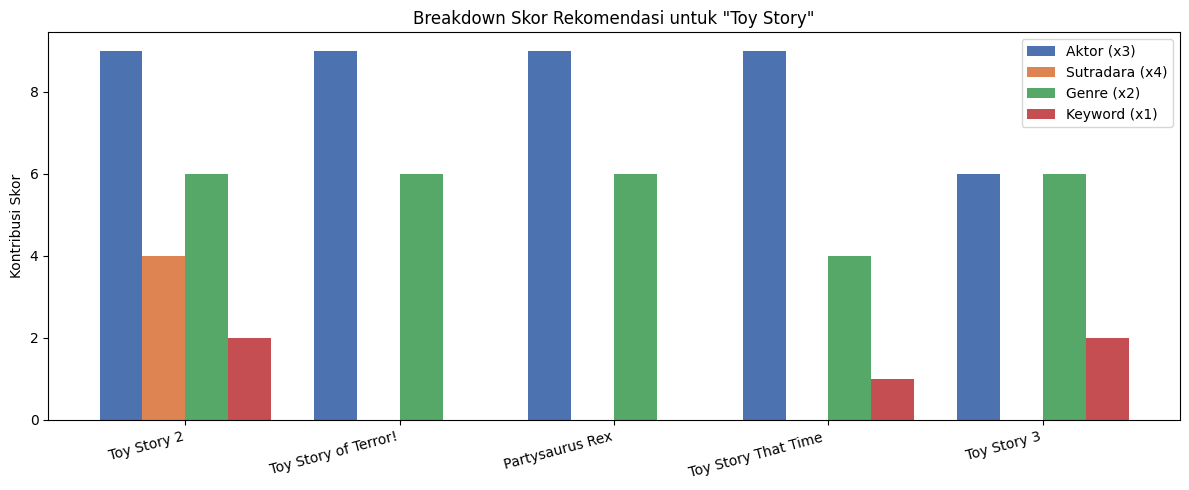

In [5]:
import matplotlib.pyplot as plt
import numpy as np

if not hasil.empty:
    top5 = hasil.head(5).copy()
    top5['skor_aktor']    = top5['aktor']    * 3
    top5['skor_sutradara']= top5['sutradara'] * 4
    top5['skor_genre']    = top5['genre']    * 2
    top5['skor_keyword']  = top5['keyword']  * 1

    labels = top5['rekomendasi'].str[:20]
    x = np.arange(len(labels))
    w = 0.2

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - 1.5*w, top5['skor_aktor'],     w, label='Aktor (x3)',     color='#4C72B0')
    ax.bar(x - 0.5*w, top5['skor_sutradara'], w, label='Sutradara (x4)', color='#DD8452')
    ax.bar(x + 0.5*w, top5['skor_genre'],     w, label='Genre (x2)',     color='#55A868')
    ax.bar(x + 1.5*w, top5['skor_keyword'],   w, label='Keyword (x1)',   color='#C44E52')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_ylabel('Kontribusi Skor')
    ax.set_title(f'Breakdown Skor Rekomendasi untuk "{film}"')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## Rekomendasi Interaktif — Input Bebas

In [6]:
# Cari dulu judul film yang tersedia
df_titles = query("""
    MATCH (m:Movie) RETURN m.title AS title
    ORDER BY m.title LIMIT 20
""")
print('Contoh judul film yang tersedia:')
print(df_titles['title'].tolist())

Contoh judul film yang tersedia:
['!Women Art Revolution', '#1 Cheerleader Camp', '#Horror', '#chicagoGirl', '$1,000 on the Black', '$100,000 for Ringo', '$5 a Day', '$50K and a Call Girl: A Love Story', '$9.99', '$ellebrity', "'49-'17", "'71", "'D'", "'Gator Bait", "'Master Harold'... and the Boys", "'Neath the Arizona Skies", "'R Xmas", "'Til Madness Do Us Part", "'Tis the Season for Love", "'Twas the Night"]


In [7]:
# Ganti judul di bawah ini dengan film pilihan kamu
film_pilihan = "Jumanji"

hasil_pilihan = rekomendasi_film(film_pilihan, top_n=10)
print(f'Rekomendasi untuk "{film_pilihan}":')
hasil_pilihan

Rekomendasi untuk "Jumanji":


,rekomendasi,skor_total,aktor,sutradara,genre,keyword
0,Night at the Museum,10,1,0,3,1
1,Aladdin,9,1,0,3,0
2,Hook,9,1,0,3,0
3,Night at the Museum: Secret of the Tomb,9,1,0,3,0
4,Night at the Museum: Battle of the Smithsonian,9,1,0,3,0
5,Small Soldiers,7,1,0,2,0
6,Aladdin and the King of Thieves,7,1,0,2,0
7,Cars,7,1,0,2,0
8,Spider-Man 3,7,1,0,2,0
9,Cars 3,7,1,0,2,0


In [8]:
driver.close()
print('Koneksi ditutup.')

Koneksi ditutup.
